In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

random.seed(42)
np.random.seed(42)

n = 500

customer_ids = [f'CUST{str(i).zfill(4)}' for i in range(1, n+1)]
plans = random.choices(['Basic', 'Pro', 'Enterprise'], weights=[50, 35, 15], k=n)
countries = random.choices(['Nigeria', 'USA', 'UK', 'Canada', 'Ghana', 'Kenya'], weights=[30, 25, 15, 10, 10, 10], k=n)
signup_dates = [datetime(2021, 1, 1) + timedelta(days=random.randint(0, 900)) for _ in range(n)]
monthly_spend = [round(random.uniform(10, 500), 2) for _ in range(n)]
logins_per_month = [random.randint(1, 60) for _ in range(n)]
support_tickets = [random.randint(0, 10) for _ in range(n)]
churned = random.choices([0, 1], weights=[65, 35], k=n)

# Add some missing values
for col in [monthly_spend, logins_per_month, support_tickets]:
    for i in random.sample(range(n), 20):
        col[i] = None

df = pd.DataFrame({
    'customer_id': customer_ids,
    'plan': plans,
    'country': countries,
    'signup_date': signup_dates,
    'monthly_spend': monthly_spend,
    'logins_per_month': logins_per_month,
    'support_tickets': support_tickets,
    'churned': churned
})

df.to_csv('customer_data.csv', index=False)
print('Dataset generated and saved')
print(df.shape)

Dataset generated and saved
(500, 8)


In [2]:
import pandas as pd

In [4]:
df=pd.read_csv(r"C:\Users\Hp\customer_data.csv")
print(df)

    customer_id   plan  country signup_date  monthly_spend  logins_per_month  \
0      CUST0001    Pro       UK  2021-04-12         175.80              18.0   
1      CUST0002  Basic  Nigeria  2022-12-04         302.96              19.0   
2      CUST0003  Basic      USA  2022-01-12         396.72               8.0   
3      CUST0004  Basic       UK  2022-07-12         327.18              37.0   
4      CUST0005    Pro  Nigeria  2022-10-23          42.30              44.0   
..          ...    ...      ...         ...            ...               ...   
495    CUST0496    Pro  Nigeria  2022-01-17         355.44              44.0   
496    CUST0497  Basic      USA  2021-10-17         165.35               NaN   
497    CUST0498  Basic      USA  2022-02-01         180.91              39.0   
498    CUST0499  Basic    Kenya  2022-02-23         467.51               3.0   
499    CUST0500  Basic    Ghana  2023-03-05         399.75              56.0   

     support_tickets  churned  
0      

In [6]:
df.head()

,customer_id,plan,country,signup_date,monthly_spend,logins_per_month,support_tickets,churned
0,CUST0001,Pro,UK,2021-04-12,175.80,18.0,NaN,0
1,CUST0002,Basic,Nigeria,2022-12-04,302.96,19.0,3.0,1
2,CUST0003,Basic,USA,2022-01-12,396.72,8.0,9.0,1
3,CUST0004,Basic,UK,2022-07-12,327.18,37.0,10.0,1
4,CUST0005,Pro,Nigeria,2022-10-23,42.30,44.0,8.0,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       500 non-null    object 
 1   plan              500 non-null    object 
 2   country           500 non-null    object 
 3   signup_date       500 non-null    object 
 4   monthly_spend     480 non-null    float64
 5   logins_per_month  480 non-null    float64
 6   support_tickets   480 non-null    float64
 7   churned           500 non-null    int64  
dtypes: float64(3), int64(1), object(4)
memory usage: 31.4+ KB


In [9]:
df.shape

(500, 8)

In [10]:
df['monthly_spend']=df['monthly_spend'].fillna(df['monthly_spend'].median())

In [11]:
df['logins_per_month']=df['logins_per_month'].fillna(df['logins_per_month'].median())

In [12]:
df['support_tickets']=df['support_tickets'].fillna(df['support_tickets'].median())

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       500 non-null    object 
 1   plan              500 non-null    object 
 2   country           500 non-null    object 
 3   signup_date       500 non-null    object 
 4   monthly_spend     500 non-null    float64
 5   logins_per_month  500 non-null    float64
 6   support_tickets   500 non-null    float64
 7   churned           500 non-null    int64  
dtypes: float64(3), int64(1), object(4)
memory usage: 31.4+ KB


In [14]:
df['signup_date']= pd.to_datetime(df['signup_date'])
print(df['signup_date'].dtype)

datetime64[ns]


In [15]:
df.to_csv('improved_customer_data.csv', index= False)
print('File Saved Successfully')

File Saved Successfully


In [20]:
 df.groupby(df['plan'])['monthly_spend'].mean()

plan
Basic         263.965847
Enterprise    264.426506
Pro           254.325917
Name: monthly_spend, dtype: float64

In [23]:
df.groupby(['plan'])['monthly_spend'].sum()

plan
Basic         65463.53
Enterprise    21947.40
Pro           42981.08
Name: monthly_spend, dtype: float64

In [24]:
import matplotlib.pyplot as plt

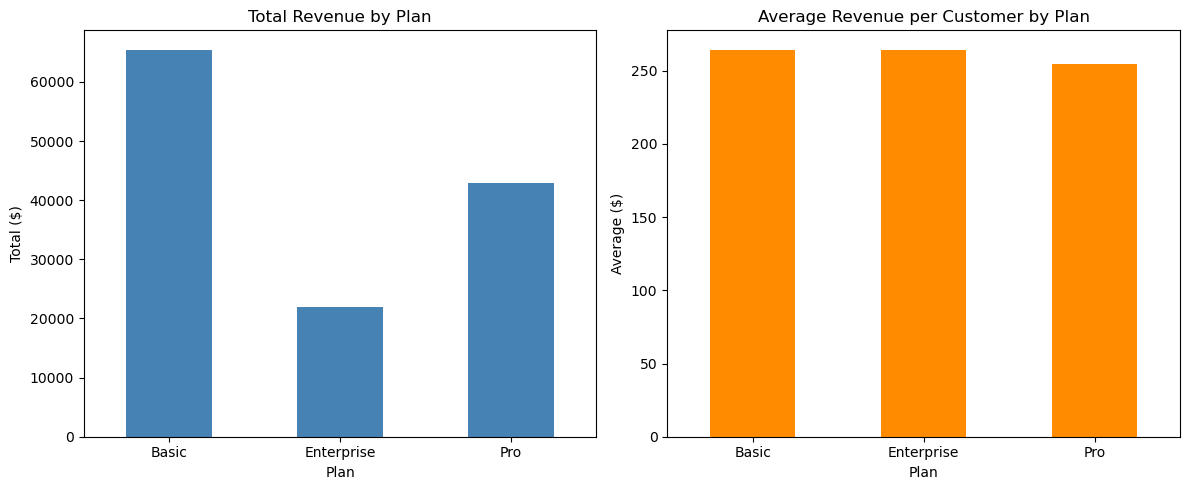

In [57]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

plan_analysis['Total_Revenue'].plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Total Revenue by Plan')
ax1.set_xlabel('Plan')
ax1.set_ylabel('Total ($)')
ax1.tick_params(axis='x', rotation=0)

plan_analysis['Average_Revenue'].plot(kind='bar', ax=ax2, color='darkorange')
ax2.set_title('Average Revenue per Customer by Plan')
ax2.set_xlabel('Plan')
ax2.set_ylabel('Average ($)')
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('total_revenue_by_plan.png', bbox_inches='tight', dpi=150)
plt.savefig('average_revenue_by_plan.png', bbox_inches='tight', dpi=150)
plt.show()


In [37]:
df.groupby('country')['churned'].mean().sort_values(ascending=False)

country
Ghana      0.395833
Nigeria    0.380597
UK         0.367816
Canada     0.346154
Kenya      0.333333
USA        0.303279
Name: churned, dtype: float64

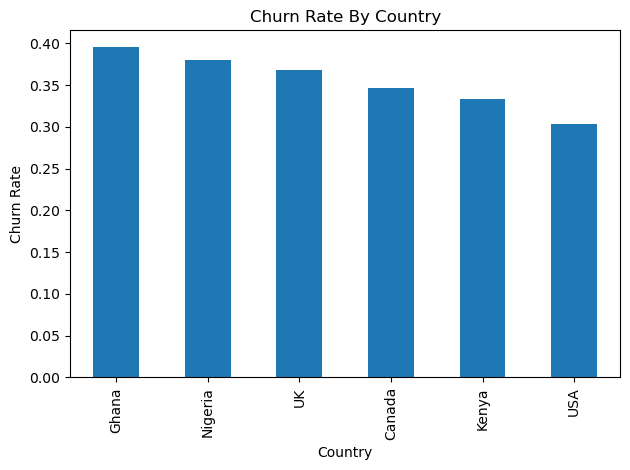

In [58]:
Churn_rate_by_Country = df.groupby('country')['churned'].mean().sort_values(ascending=False)
Churn_rate_by_Country.plot(kind='bar')
plt.title('Churn Rate By Country')
plt.xlabel('Country')
plt.ylabel('Churn Rate')
plt.tight_layout()
plt.savefig('churn_rate_by_country.png', bbox_inches='tight', dpi=150)
plt.show()

In [43]:
df.groupby('churned')['logins_per_month'].mean()

churned
0    31.296296
1    31.232955
Name: logins_per_month, dtype: float64

In [44]:
df.groupby('churned')['support_tickets'].mean()

churned
0    5.348765
1    4.863636
Name: support_tickets, dtype: float64

In [45]:
df.groupby('churned')['monthly_spend'].mean()

churned
0    253.858611
1    273.533068
Name: monthly_spend, dtype: float64

In [46]:
df.groupby('plan')['churned'].mean()

plan
Basic         0.375000
Enterprise    0.397590
Pro           0.295858
Name: churned, dtype: float64

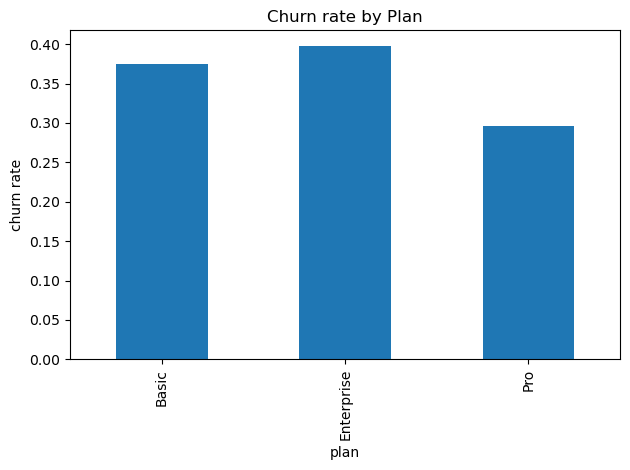

In [59]:
churn_rate_by_plan= df.groupby('plan')['churned'].mean()
churn_rate_by_plan.plot(kind='bar')
plt.title('Churn rate by Plan')
plt.xlabel('plan')
plt.ylabel('churn rate')
plt.tight_layout()
plt.savefig('churn_rate_by_plan.png', bbox_inches='tight', dpi=150)
plt.show()
